# SAC(Soft Actor-Critic)을 이용한 Walker2D 학습

먼저, 아래 링크를 통해 walker2D 환경과 SAC 알고리즘에 대해 참고하자.

walker2d : https://gymnasium.farama.org/environments/mujoco/walker2d/

stable-baselines3: https://stable-baselines3.readthedocs.io/en/master/modules/sac.html

In [ ]:
# 만약 환경 구성이 안되어 있다면 아래 코드(주석 해제하고)를 통해 환경 설치

# !pip install stable-baselines3[extra] gymnasium[mujoco] tensorboard matplotlib


In [10]:
import gymnasium as gym
import mujoco
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import CheckpointCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
import os
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing import event_accumulator

In [15]:
## 테스트 해보기

# 환경 생성
env = gym.make("Walker2d-v4", render_mode="human")

# 학습 안 된 SAC 모델 (랜덤 초기 가중치)(gpu 사용이 안된다면 device="cpu"로 설정하거나 device부분을 빼버리면 자동으로 cpu 연산)
init_model = SAC("MlpPolicy", env, verbose=0, device="cuda")

# 환경 실행
obs, _ = env.reset()
for step in range(1000):  # 1000 스텝 정도 시뮬레이션
    # 학습 전 모델은 사실상 랜덤 행동(계속 넘어질 것임)
    action, _ = init_model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = env.step(action)
    if done or truncated:
        obs, _ = env.reset()

env.close()

In [3]:
# 로그 및 모델 저장 폴더 생성
log_dir = "./SAClogs/sac_walker2d/"
model_dir = "./SACmodels/sac_walker2d/"
os.makedirs(log_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

In [4]:
# 환경 생성(Moiniter로 보상/에피소드 길이 추적)
env = DummyVecEnv([lambda: Monitor(gym.make("Walker2d-v4"))])

c:\Users\Yang_seungwon\miniconda3\envs\RL\Lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment Walker2d-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


In [5]:
# SAC 모델 생성(tensorboard_log를 저장)
model = SAC(
    "MlpPolicy",
    env,
    tensorboard_log=log_dir,
    verbose=1,
    device="cuda"
)

Using cuda device


In [7]:
# 50,000 스텝마다 모델 저장
checkpoint_callback = CheckpointCallback(
    save_freq=50_000,            # 저장 주기
    save_path=model_dir,         # 저장 경로
    name_prefix="sac_walker2d",  # 파일명 접두어
    save_replay_buffer=True,     # 리플레이 버퍼도 저장
)

In [8]:
## 학습 실행(tensorboard 로그 기록도 저장)

# 총 학습 스텝 수
total_timesteps = 300_000

# 모델 학습
model.learn(
    total_timesteps=total_timesteps,
    callback=checkpoint_callback,
    tb_log_name="SAC_Walker2d_Default",
)

Logging to ./SAClogs/sac_walker2d/SAC_Walker2d_Default_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 25.8     |
|    ep_rew_mean     | 7.18     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 690      |
|    time_elapsed    | 0        |
|    total_timesteps | 103      |
| train/             |          |
|    actor_loss      | -3.39    |
|    critic_loss     | 9.91     |
|    ent_coef        | 1        |
|    ent_coef_loss   | -0.00266 |
|    learning_rate   | 0.0003   |
|    n_updates       | 2        |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 25.1     |
|    ep_rew_mean     | 6.01     |
| time/              |          |
|    episodes        | 8        |
|    fps             | 164      |
|    time_elapsed    | 1        |
|    total_timesteps | 201      |
| train/             |          |
|    actor_loss      | -9

## 로그 확인

### rollout/ — 환경에서 수집된 에피소드 통계

ep_len_mean: 최근 에피소드들의 평균 길이 (step 수). 학습이 잘 되면 점점 길어져 오래 서 있거나 잘 걷는다는 뜻

ep_rew_mean: 최근 에피소드들의 평균 누적 보상. 학습이 진행될수록 증가하면 성능이 좋아지는 중

### time/ — 학습 진행 상태

episodes: 지금까지 종료된 에피소드의 수

fps: 학습 중 초당 처리되는 스탭 수

time_elapsed: 학습 시작 이후 경과 시간(초)

total_timesteps: 지금까지 학습된 총 타임스탭 수

### train/ — 신경망(Actor/Critic/Entropy) 관련 손실 및 학습 지표

actor_loss: 정책 네트워크(π)의 손실. 보통 음수이며, 작을수록 정책이 안정화됨

critic_loss: Q함수 손실. 평균제곱오차(MSE) 기반이며 값이 작을수록 타깃 Q와 일치함

ent_coef: 현재 엔트로피 계수(α). 탐험(↑)과 활용(↓) 사이 균형 조절 파라미터

ent_coef_loss: α의 학습 손실. target entropy에 맞게 α가 조정되는 정도

learning_rate: 현재 학습률

n_updates: 지금까지 수행된 gradient update 횟수



In [22]:
## 학습된 모델 불러와 시각화

#환경 초기화 및 모델 선택(불러올 모델 이름의 time_steps을 지정하여 변경 가능)
env = gym.make("Walker2d-v4", render_mode="human")
loaded_model = SAC.load(model_dir + "sac_walker2d_300000_steps")

# 카메라 설정(walker2D 모델을 따라가도록 카메라 설정)(시뮬레이션 시작하고 tab키로 카메라 id 지정)
def set_camera(env):
    """reset 이후 viewer 새로 가져와 카메라 재설정"""
    viewer = env.unwrapped.mujoco_renderer.viewer
    mujoco_model = env.unwrapped.model
    torso_id = mujoco.mj_name2id(mujoco_model, mujoco.mjtObj.mjOBJ_BODY, "torso")

    viewer.cam.trackbodyid = torso_id   # 중심 body 따라가기
    viewer.cam.distance = 5.0   # 카메라 거리
    viewer.cam.azimuth = 90     # ← 좌우 회전: 0이면 정면, 90이면 옆모습
    viewer.cam.elevation = -10  # ← 위/아래 각도 (약간 내려다보기)
    viewer.cam.lookat[:] = [0, 0, 1.0]  # 카메라가 바라보는 중심 (z=1 정도 높이)

# 첫 reset에서 카메라 설정
obs, _ = env.reset()
set_camera(env)

for step in range(5000):
    action, _ = loaded_model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = env.step(action)

    if done or truncated:
        #reset 후 viewer가 새로 생성되므로 카메라 재설정 필요
        obs, _ = env.reset()
        set_camera(env)

env.close()

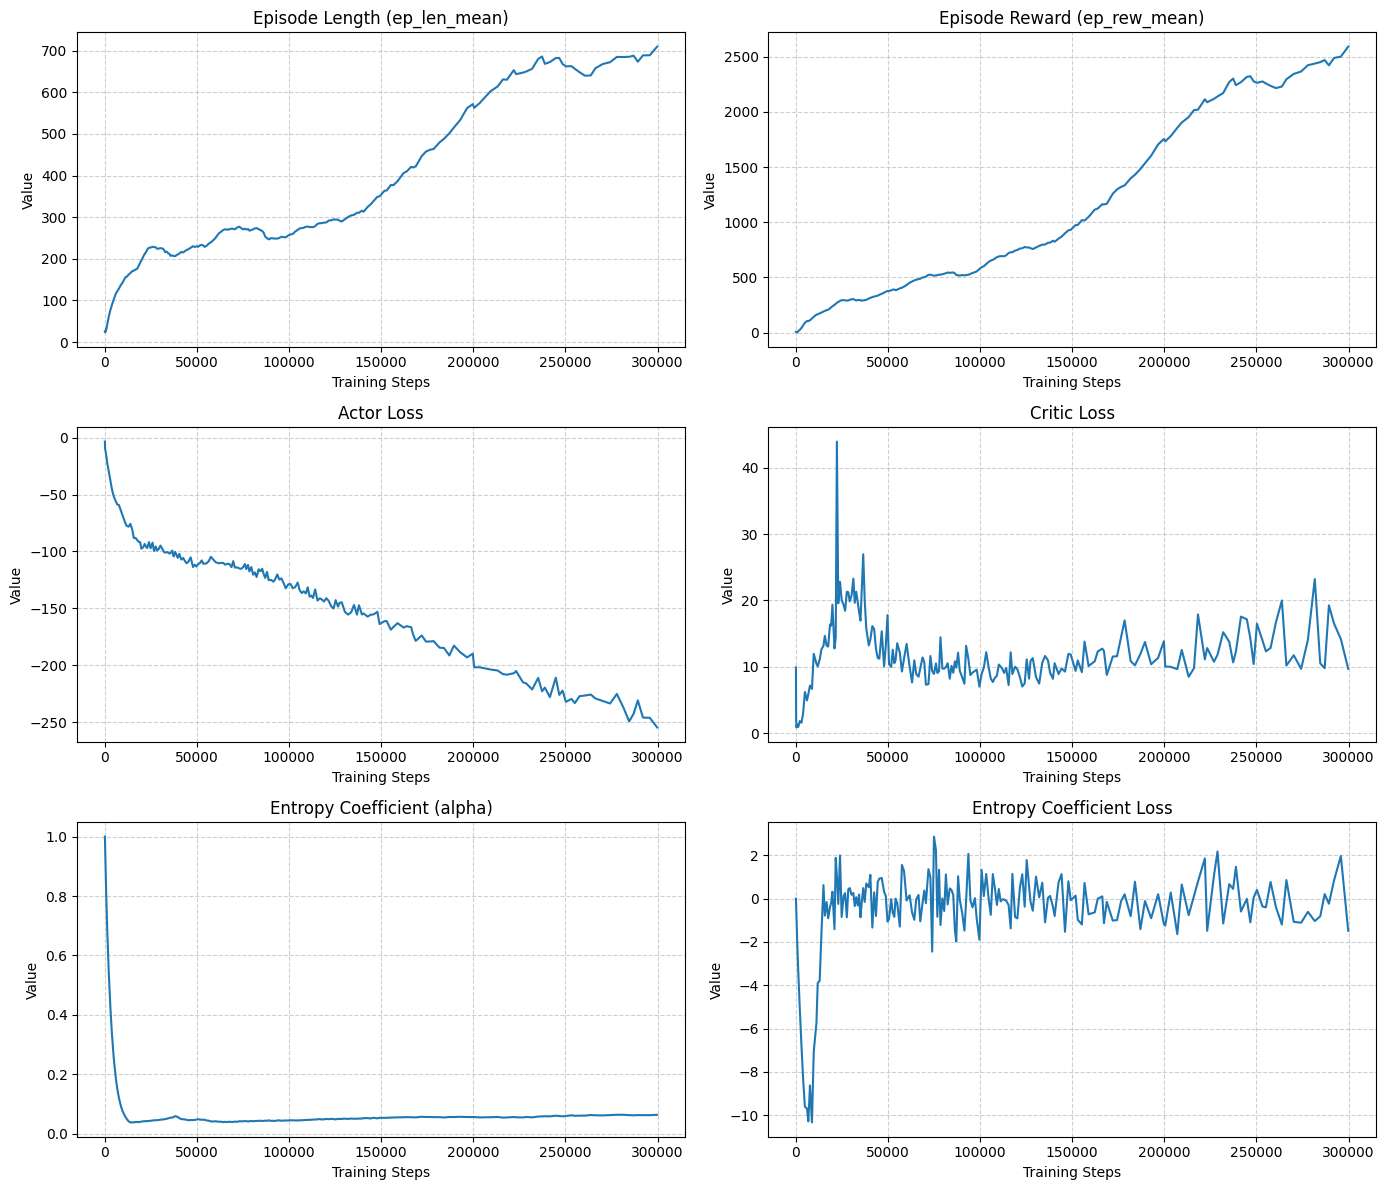

In [23]:
## tensorboard 로그를 matplot 시각화

# 이벤트 파일 읽기 (가장 최근 로그 디렉토리)
ea = event_accumulator.EventAccumulator(log_dir + "SAC_Walker2d_Default_1/")
ea.Reload()

# 시각화할 지표 이름과 표시 제목 매핑
metrics = {
    "rollout/ep_len_mean": "Episode Length (ep_len_mean)",
    "rollout/ep_rew_mean": "Episode Reward (ep_rew_mean)",
    "train/actor_loss": "Actor Loss",
    "train/critic_loss": "Critic Loss",
    "train/ent_coef": "Entropy Coefficient (alpha)",
    "train/ent_coef_loss": "Entropy Coefficient Loss"
}

# subplot 구성 (3행 2열)
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (tag, title) in enumerate(metrics.items()):
    try:
        events = ea.Scalars(tag)
        steps = [x.step for x in events]
        values = [x.value for x in events]
        axes[idx].plot(steps, values, label=tag)
        axes[idx].set_title(title)
        axes[idx].set_xlabel("Training Steps")
        axes[idx].set_ylabel("Value")
        axes[idx].grid(True, linestyle="--", alpha=0.6)
    except KeyError:
        axes[idx].text(0.5, 0.5, f"{tag}\nnot found", 
                       ha='center', va='center', fontsize=10, color='gray')
        axes[idx].set_axis_off()

plt.tight_layout()
plt.show()

그래프를 살펴보면, actor-loss는 monotonic하게 잘 감소하는 것을 확인할 수 있었다.
반면, critic-loss는 초반에 10부터 40까지 증가했다가 다시 10 부근으로 감소하되 상당히 진동 패턴이 많고 학습이 불안정하다.
또한 entropy-coef loss는 0에서 시작하여 -10까지 잘 떨어졌다가 다시 0부근으로 상승한뒤 0부근에서 진동하고 있다.

전반적으로 학습을 더 안정화 시키려면 스케일을 정규화 하기 위해 관측 및 보상을 정규화 하는 방법이 있는데,

from stable_baselines3.common.vec_env import VecNormalize 

env = DummyVecEnv([lambda: gym.make("Walker2d-v4")])

env = VecNormalize(env, norm_obs=True, norm_reward=True, clip_obs=10.0, clip_reward=10.0)

위와 같이 정규화를 수행할 수 있다고 한다.
또한, 일반적으로 진동을 줄이기 위해서 학습률을 줄이거나 배치크기 높이기(타깃 분산이 줄어듬), gradient_steps 조절하기, 타깃 업데이트를 더 보수적으로 하기 위해 tau값 더욱 줄이기(기본값 0.005) 등을 고려해 볼 수 있다.